### ÁRBOL DE DECISÓN Y BOSQUE ALEATORIO

# PARTE 1: Árbol de Decisión (Decision Tree)

## 1. Librerías

In [22]:
!pip install pydotplus


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import numpy as np
import pandas as pd
import pydotplus
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn import tree 
from IPython.display import Image

## 2. Carga de datasets

In [24]:
mydate = load_iris()

x = mydate.data
y = mydate.target

print(x.shape)
print(y.shape)

(150, 4)
(150,)


Contamos con 150 registro, c/clase 50 registros.

# 3. Análisis General

## 3.1 Variables de Entrada:

In [25]:
mydate.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## Clases que se quieren predecir (y):

In [26]:
 mydate.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

4. ENTRENAMIENTO, VALIDACIÓN Y PRUEBA

## 4.1 Pre entrenamiento

### 4.1.1 Train Split: Entrenamiento, Validación y Prueba. 

In [27]:
x_tv, x_test, y_tv, y_test = train_test_split(
    x, y,
    test_size=.2,
    shuffle=True,
    random_state=1
)

x_train, x_val, y_train, y_val = train_test_split(
    x_tv, y_tv,
    test_size=.25,
    shuffle=True,
    random_state=1
)
print('Tamaño del conjunto de entrenamiento:', x_train.shape)
print('Tamaño del conjunto de validación:', x_val.shape)
print('Tamaño del conjunto de prueba:', x_test.shape)

Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba: (30, 4)


### 4.1.2 Gráfico Bigotes de las Variables de Entrada:


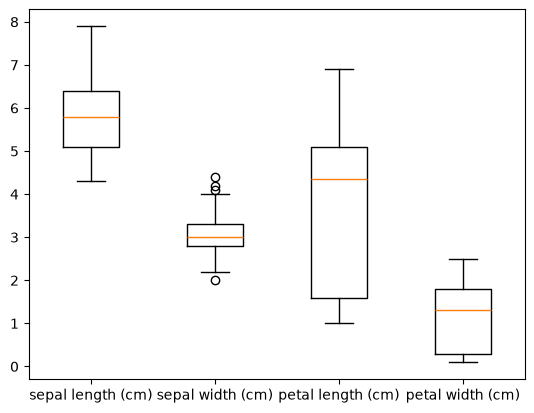

In [28]:
plt.boxplot(x, tick_labels=mydate.feature_names)
plt.show()

Hallazgos:
* sepal width presenta algunos valores atípicos.
* petal length y petal width muestran una dispersión importante.
* sepal length también tiene variabilidad, pero un poco más moderada.

## 4.2 Entrenamiento y Validación

### 4.2.1 Construcción y evaluación preliminar del modelo

In [29]:
modeloDT = DecisionTreeClassifier()   # Incializamos el modelo con los hiperparámetros predeterminados.

clf = modeloDT.fit(x_train, y_train)   # Entrenamos con el conjunto de entrenamiento para obtener nuestro primer clasificador (clf)
# Podemos observar el desempeño en el conjunto de entrenamieto para verificar
# el subentrenamiento o sobreentrenamiento, pero no para evaluar el modelo en sí:
print('Exactitud en el conjunto de entrenamiento: %.2f' % clf.score(x_train, y_train))
# Así, el conjunto con el que nos interesa evaluar el desempeño es con los de validación,
# así que calculamos primero sus predicciones y después las usamos para evaluar el modelo:
predi = clf.predict(x_val)     # Obtenemos predicciones de 0s, 1s o 2s para cada clase
print('Exactitud en el conjunto de validación: %.2f' % clf.score(x_val, y_val))

Exactitud en el conjunto de entrenamiento: 1.00
Exactitud en el conjunto de validación: 0.97


Hallazgos:
El modelo de Árbol de Decisión alcanzó una exactitud del 100% en el conjunto de entrenamiento y del 97% en el conjunto de validación. Esto indica que el modelo aprendió muy bien los patrones de los datos,

## 4.2.2 Mátrix de Confusión

In [30]:
[[ 9,  0,  0],
 [ 0, 10,  0],
 [ 0,  1, 10]]

[[9, 0, 0], [0, 10, 0], [0, 1, 10]]

Hallazgos:
    * Setosa: 9 correctamente clasificadas.
    * Versicolor: 10 correctamente clasificadas.
    * Virginica: 10 correctamente clasificadas y 1 érronea.
El modelo tuvo un desempeño excelente, porque casi todas las predicciones fueron correctas y solo hubo una confusión entre dos clases parecidas.

## 4.2.3 Modelo Árbol de Decisiones

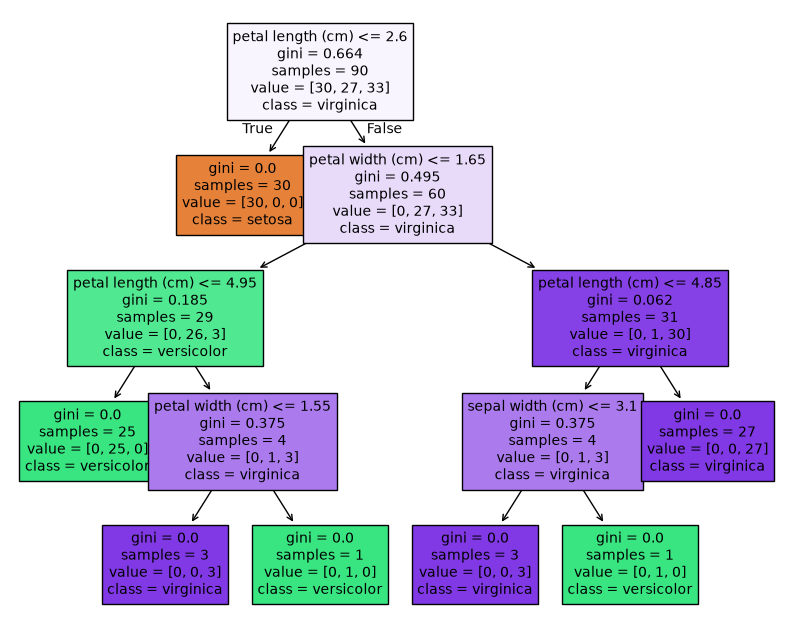

In [31]:

plt.figure(figsize=(10, 8))
tree.plot_tree(
    clf,
    feature_names=mydate.feature_names,
    class_names=mydate.target_names,
    filled=True,
    fontsize=10
)
plt.show()

Hallazgos:
* Setosa se separa muy fácilmente.
* Cuando gini llega a 0.0, significa que esa decisión dejó una clasificación perfecta en ese nodo.

# Parte 2: Ramdom Forest

# 1. Generar data

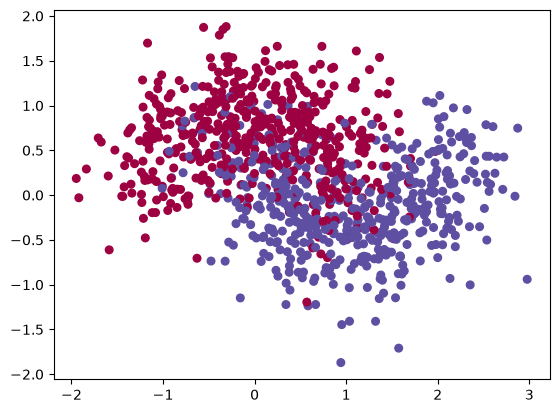

In [32]:
from sklearn.datasets import make_moons
N = 1000  # total de datos a generar en la muestra
noisy_data = make_moons(
    n_samples=N,
    noise=0.4,
    random_state=17
)
X, Y = noisy_data
plt.scatter(X[:,0], X[:,1], c=Y, s=30, cmap=plt.cm.Spectral)
plt.show()

Hallazgos:
* Los datos generados presentan dos clases con una estructura no lineal.
* Se observa un solapamiento importante entre ambas clases.
* En este contexto, Random Forest resulta una opción adecuada, ya que puede modelar fronteras de decisión complejas.

# 2. Entrenamiento y Prueba

## 2.1 Modelo Random Forest     
Modelado
Train Split
Mátriz de Confusión 

In [33]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=.4, shuffle=True, random_state=17)
mimodelo = RandomForestClassifier()
clf = mimodelo.fit(Xtrain,Ytrain)
results = clf.predict(Xtest)
confusion_matrix(Ytest, results)

array([[165,  37],
       [ 31, 167]])

Hallazgos:
* El modelo acertó 164 + 167 = 331 casos.
* Se equivocó en 38 + 31 = 69 casos.

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=17
)

clf.score(X_test, Y_test) # es la Exactitud (accuracy)

0.85

Hallazgos:
* 400 datos de prueba, la exactitud es aproximadamente 82.75%
* El modelo tiene un desempeño bueno, pero no perfecto y se debe al ruido y traslape.

## 2.2 Hiperparámetros

In [ ]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:
mimodelo2 = RandomForestClassifier(n_estimators=10,             
                                   criterion='gini',               
                                   max_leaf_nodes=16
)

In [ ]:
# solo nos quedamos con las mejores k hojas.
mimodelo2 = RandomForestClassifier(
    n_estimators=10,                    # número de árboles en el Forest y después promedia por votación.
    criterion='gini',                    # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
    max_depth=2,                        # Depth=k : máximo 2^k líneas/ramas.    
    min_samples_split=6,                # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1. 
    min_samples_leaf=4,                 # # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1. # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).
    max_features='sqrt',
    max_leaf_nodes=16,
    bootstrap=True,                     # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set. 
                           
    oob_score=True,                     # En caso de utilizar Out-of-bag samples.
                                
                                     # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0].
    verbose=0,                          # tipo de despliega de información durante el entrenamiento.
    n_jobs=-1,                          # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles. 
    max_samples=None,                   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0]. 
    random_state=19
)

In [39]:
clf2 = mimodelo2.fit(Xtrain, Ytrain)
results2 = clf2.predict(Xtest)
print(confusion_matrix(Ytest, results2))

[[170  32]
 [ 26 172]]


c:\Users\Eve\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Hallazgos: 
El modelo Random Forest ajustado presentó un mejor desempeño en comparación con la versión anterior, logrando clasificar correctamente 342 de 400 observaciones, con una exactitud aproximada de 85.5%. Los errores se redujeron en ambas clases, lo que indica una mejora en la capacidad predictiva del modelo.